In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)

df['MedHouseVal'] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
print("Shape of dataset:", df.shape)

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nSummary statistics:")
df.describe()

Shape of dataset: (20640, 9)

Missing values in each column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Summary statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [5]:
print(df.info())

print("\nCorrelation with target variable:")
print(df.corr()['MedHouseVal'].sort_values(ascending=False))

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Correlation with target variable:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


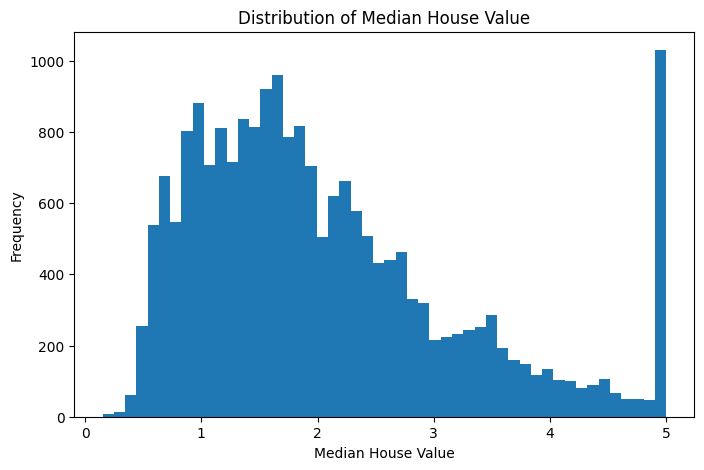

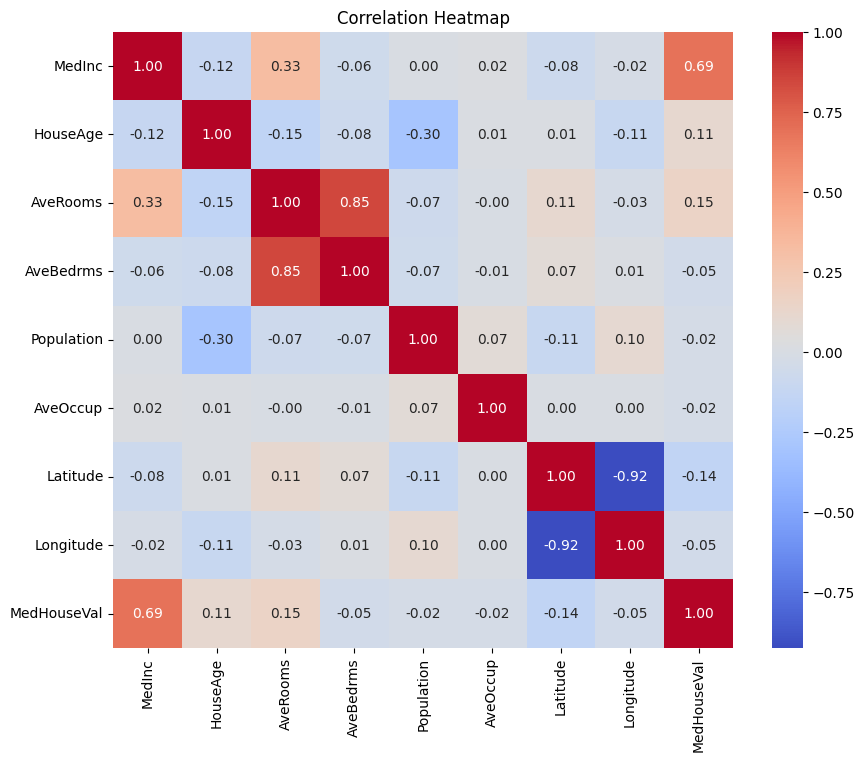

In [6]:
plt.figure(figsize=(8,5))
plt.hist(df['MedHouseVal'], bins=50)
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.title('Distribution of Median House Value')
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [7]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (16512, 8)
Testing set shape: (4128, 8)


In [8]:
lin_reg = LinearRegression()

lin_reg.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [9]:
print("Coefficients (weights):")
for feature, coef in zip(X.columns, lin_reg.coef_):
    print(f"{feature}: {coef}")

print("\nIntercept:", lin_reg.intercept_)

Coefficients (weights):
MedInc: 0.44867490966571805
HouseAge: 0.0097242575179049
AveRooms: -0.12332334282795997
AveBedrms: 0.7831449067929749
Population: -2.0296205801018097e-06
AveOccup: -0.0035263184871341014
Latitude: -0.41979248658836005
Longitude: -0.43370806496398745

Intercept: -37.02327770606416


In [10]:
y_pred = lin_reg.predict(X_test)

print("First 5 Predicted Values:", y_pred[:5])
print("First 5 Actual Values:", y_test[:5].values)

First 5 Predicted Values: [0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]
First 5 Actual Values: [0.477   0.458   5.00001 2.186   2.78   ]


In [11]:
mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R-squared (R2) Score:", r2)

Mean Squared Error (MSE): 0.5558915986952442
R-squared (R2) Score: 0.575787706032451


In [12]:
split_ratios = [0.4, 0.3, 0.2, 0.1]
split_names = ['60:40', '70:30', '80:20', '90:10']

linear_results = {}

for ratio, name in zip(split_ratios, split_names):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=ratio, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    linear_results[name] = {'MSE': mse, 'R2': r2}
    
    print(f"Split {name} -> MSE: {mse:.4f}, R2: {r2:.4f}")

linear_results_df = pd.DataFrame(linear_results).T
print("Linear Regression Results for Different Splits:")
linear_results_df

Split 60:40 -> MSE: 0.5436, R2: 0.5939
Split 70:30 -> MSE: 0.5306, R2: 0.5958
Split 80:20 -> MSE: 0.5559, R2: 0.5758
Split 90:10 -> MSE: 0.5590, R2: 0.5808
Linear Regression Results for Different Splits:


,MSE,R2
60:40,0.543595,0.593940
70:30,0.530568,0.595770
80:20,0.555892,0.575788
90:10,0.559002,0.580835


In [13]:
alpha_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]

split_ratios = [0.4, 0.3, 0.2, 0.1]
split_names = ['60:40', '70:30', '80:20', '90:10']

In [14]:
ridge_results = []

for ratio, name in zip(split_ratios, split_names):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=ratio, random_state=42)
    
    for alpha in alpha_values:
        ridge_model = Ridge(alpha=alpha)
        ridge_model.fit(X_train, y_train)
        
        y_pred = ridge_model.predict(X_test)
        
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        ridge_results.append({'Split': name, 'Alpha': alpha, 'MSE': mse, 'R2': r2})

ridge_results_df = pd.DataFrame(ridge_results)
print("Ridge Regression Results:")
ridge_results_df

Ridge Regression Results:


,Split,Alpha,MSE,R2
0,60:40,0.001,0.543594,0.593940
1,60:40,0.005,0.543594,0.593940
2,60:40,0.010,0.543594,0.593941
3,60:40,0.050,0.543591,0.593943
4,60:40,0.100,0.543587,0.593946
5,60:40,0.500,0.543555,0.593970
6,70:30,0.001,0.530568,0.595770
7,70:30,0.005,0.530567,0.595770
8,70:30,0.010,0.530567,0.595771
9,70:30,0.050,0.530565,0.595773


In [15]:
lasso_results = []

for ratio, name in zip(split_ratios, split_names):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=ratio, random_state=42)
    
    for alpha in alpha_values:
        lasso_model = Lasso(alpha=alpha, max_iter=10000)
        lasso_model.fit(X_train, y_train)
        
        y_pred = lasso_model.predict(X_test)
        
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        lasso_results.append({'Split': name, 'Alpha': alpha, 'MSE': mse, 'R2': r2})

lasso_results_df = pd.DataFrame(lasso_results)
print("Lasso Regression Results:")
lasso_results_df

Lasso Regression Results:


,Split,Alpha,MSE,R2
0,60:40,0.001,0.542321,0.594891
1,60:40,0.005,0.538830,0.597499
2,60:40,0.010,0.538076,0.598062
3,60:40,0.050,0.562483,0.579831
4,60:40,0.100,0.611598,0.543142
5,60:40,0.500,0.732428,0.452883
6,70:30,0.001,0.529349,0.596699
7,70:30,0.005,0.526016,0.599238
8,70:30,0.010,0.525312,0.599775
9,70:30,0.050,0.548460,0.582139


In [16]:
for name in split_names:
    print(f"\nRidge Regression Results for {name} split:")
    print(ridge_results_df[ridge_results_df['Split'] == name])

for name in split_names:
    print(f"\nLasso Regression Results for {name} split:")
    print(lasso_results_df[lasso_results_df['Split'] == name])


Ridge Regression Results for 60:40 split:
   Split  Alpha       MSE        R2
0  60:40  0.001  0.543594  0.593940
1  60:40  0.005  0.543594  0.593940
2  60:40  0.010  0.543594  0.593941
3  60:40  0.050  0.543591  0.593943
4  60:40  0.100  0.543587  0.593946
5  60:40  0.500  0.543555  0.593970

Ridge Regression Results for 70:30 split:
    Split  Alpha       MSE        R2
6   70:30  0.001  0.530568  0.595770
7   70:30  0.005  0.530567  0.595770
8   70:30  0.010  0.530567  0.595771
9   70:30  0.050  0.530565  0.595773
10  70:30  0.100  0.530562  0.595775
11  70:30  0.500  0.530536  0.595794

Ridge Regression Results for 80:20 split:
    Split  Alpha       MSE        R2
12  80:20  0.001  0.555892  0.575788
13  80:20  0.005  0.555891  0.575788
14  80:20  0.010  0.555891  0.575788
15  80:20  0.050  0.555887  0.575791
16  80:20  0.100  0.555883  0.575794
17  80:20  0.500  0.555847  0.575821

Ridge Regression Results for 90:10 split:
    Split  Alpha       MSE        R2
18  90:10  0.001  0.5

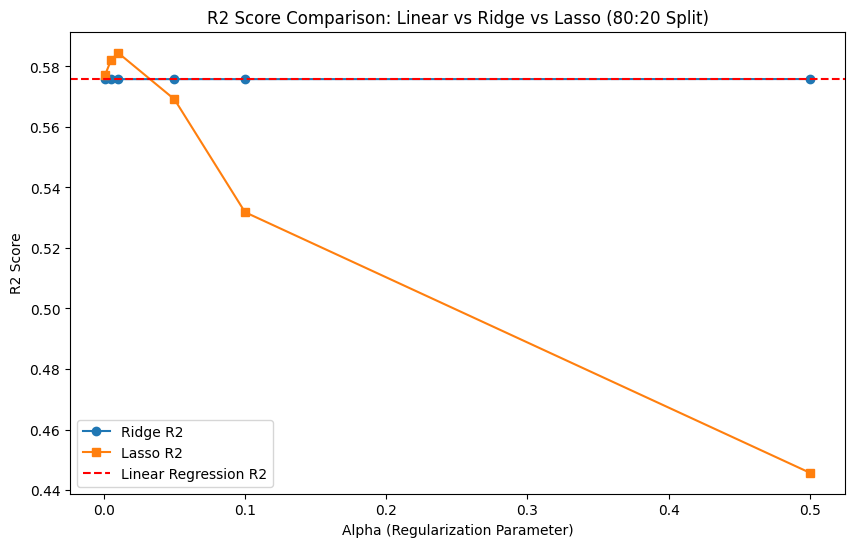

In [17]:
ridge_8020 = ridge_results_df[ridge_results_df['Split'] == '80:20']
lasso_8020 = lasso_results_df[lasso_results_df['Split'] == '80:20']

plt.figure(figsize=(10,6))
plt.plot(ridge_8020['Alpha'], ridge_8020['R2'], marker='o', label='Ridge R2')
plt.plot(lasso_8020['Alpha'], lasso_8020['R2'], marker='s', label='Lasso R2')
plt.axhline(y=linear_results['80:20']['R2'], color='r', linestyle='--', label='Linear Regression R2')

plt.xlabel('Alpha (Regularization Parameter)')
plt.ylabel('R2 Score')
plt.title('R2 Score Comparison: Linear vs Ridge vs Lasso (80:20 Split)')
plt.legend()
plt.show()

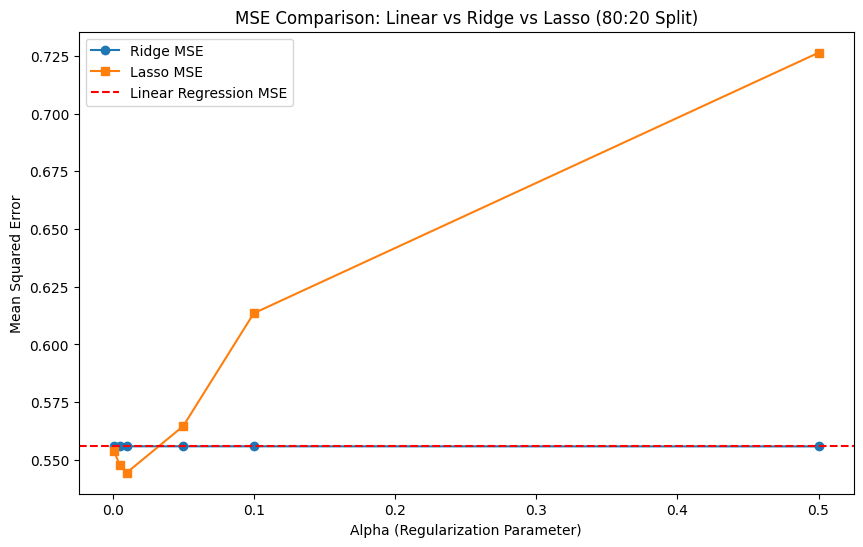

In [18]:
plt.figure(figsize=(10,6))
plt.plot(ridge_8020['Alpha'], ridge_8020['MSE'], marker='o', label='Ridge MSE')
plt.plot(lasso_8020['Alpha'], lasso_8020['MSE'], marker='s', label='Lasso MSE')
plt.axhline(y=linear_results['80:20']['MSE'], color='r', linestyle='--', label='Linear Regression MSE')

plt.xlabel('Alpha (Regularization Parameter)')
plt.ylabel('Mean Squared Error')
plt.title('MSE Comparison: Linear vs Ridge vs Lasso (80:20 Split)')
plt.legend()
plt.show()

Summary of Observations

In this assignment, I used the California Housing dataset to study Linear Regression, Ridge Regression, and LASSO Regression. The dataset was first explored using basic EDA techniques, and then different regression models were trained and tested using various train-test splits.

The Linear Regression model gave good prediction results and served as a baseline for comparison. Ridge Regression and LASSO Regression also performed similarly for smaller values of alpha. As the alpha value increased, the effect of regularization became stronger, which sometimes reduced the model performance.

I also observed that the MSE and R² scores changed slightly for different train-test splits, but the overall performance of the models remained fairly consistent. Among the tested splits, the 80:20 split provided a good balance between training and testing data.

Overall, this assignment helped me understand how regression models are trained, how their performance is evaluated using MSE and R² scores, and how regularization techniques such as Ridge and LASSO can affect model performance.
